In [34]:
# ============================================================
# MAJOR PROJECT
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [35]:
# ============================================================
# 2. UPLOAD DATASET
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully.")
print("File:", filename)
print("Dataset shape:", df.shape)

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (3).csv
Dataset loaded successfully.
File: seasonal_agriculture_performance_dataset (3).csv
Dataset shape: (4000, 28)


In [36]:
# ============================================================
# 3. BASIC DATASET EXPLORATION
# ============================================================

print("\nFIRST 5 RECORDS")
display(df.head())

print("\nDATASET SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
display(df.dtypes)


FIRST 5 RECORDS


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



DATASET SHAPE
Rows: 4000
Columns: 28

COLUMN NAMES
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

DATA TYPES


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [41]:
# ============================================================
# 4. DATA QUALITY CHECK
# ============================================================

print("MISSING VALUES")
display(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())

print("\nUNIQUE SEASONS")
print(df["Season"].unique())

print("\nUNIQUE CROPS")
print(df["Crop"].unique())

print("\nUNIQUE STATES")
print(df["State"].unique())

print("\nUNIQUE IRRIGATION METHODS")
print(df["Irrigation_Method"].unique())

MISSING VALUES


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0



DUPLICATE RECORDS
0

UNIQUE SEASONS
['Kharif' 'Rabi' 'Zaid']

UNIQUE CROPS
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

UNIQUE STATES
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

UNIQUE IRRIGATION METHODS
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [42]:
# ============================================================
# 5. DATA CLEANING
# ============================================================

original_rows = len(df)

df = df.drop_duplicates()
df = df.dropna()

print("Original rows:", original_rows)
print("Rows after cleaning:", len(df))
print("Rows removed:", original_rows - len(df))
print("Final shape:", df.shape)

Original rows: 3880
Rows after cleaning: 3880
Rows removed: 0
Final shape: (3880, 28)


In [43]:
# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns

print("DESCRIPTIVE STATISTICS")

display(df[numeric_columns].describe().T)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"3,880.00",7.88,4.22,0.50,4.25,7.88,11.60,15.00
Rainfall_mm,"3,880.00",601.68,288.33,80.00,370.98,582.90,834.60,"1,395.20"
Avg_Temperature_C,"3,880.00",26.81,3.81,16.20,24.00,26.90,29.60,39.70
Humidity_pct,"3,880.00",63.28,11.97,25.00,54.90,63.10,72.00,95.00
Sunlight_Hours_Day,"3,880.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"3,880.00",6.70,0.64,5.20,6.26,6.69,7.13,8.40
Soil_Moisture_pct,"3,880.00",26.54,6.70,8.00,21.80,26.50,31.30,47.00
Nitrogen_kg_ha,"3,880.00",120.17,31.27,40.00,98.40,119.90,141.20,220.00
Phosphorus_kg_ha,"3,880.00",57.79,17.01,15.00,46.27,57.50,69.40,120.00
Potassium_kg_ha,"3,880.00",104.63,27.68,30.00,86.10,105.10,123.50,200.00


NUMBER OF FARMS BY SEASON


,count
Season,
Kharif,1735
Rabi,1576
Zaid,569


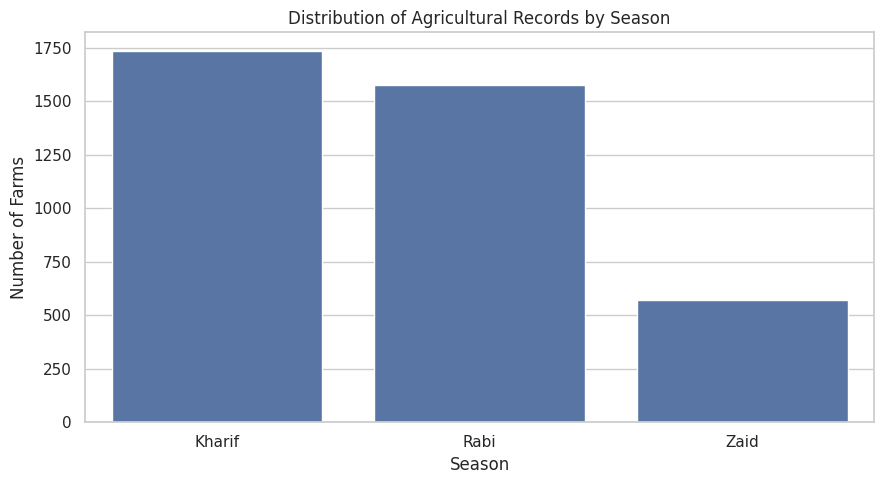

In [44]:
# ============================================================
# 7. SEASON DISTRIBUTION
# ============================================================

season_counts = df["Season"].value_counts()

print("NUMBER OF FARMS BY SEASON")
display(season_counts)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Season"
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# 8. SEASONAL PERFORMANCE SUMMARY
# ============================================================

season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Humidity=("Humidity_pct", "mean"),
    Average_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

print("SEASONAL AGRICULTURAL PERFORMANCE")
display(season_summary)

SEASONAL AGRICULTURAL PERFORMANCE


,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Rainfall,Average_Temperature,Average_Humidity,Average_Pest_Risk
Season,,,,,,,,,,,
Kharif,5.67,46.51,"712,489.58","530,950.56","181,539.02","6,053.39",5.93,850.66,28.44,71.83,54.45
Rabi,4.98,40.65,"598,348.82","512,126.73","86,222.09","5,791.91",5.14,436.83,23.49,57.95,40.52
Zaid,4.64,39.34,"518,555.62","545,191.30","-26,635.69","6,481.22",4.44,299.07,31.04,51.96,38.11


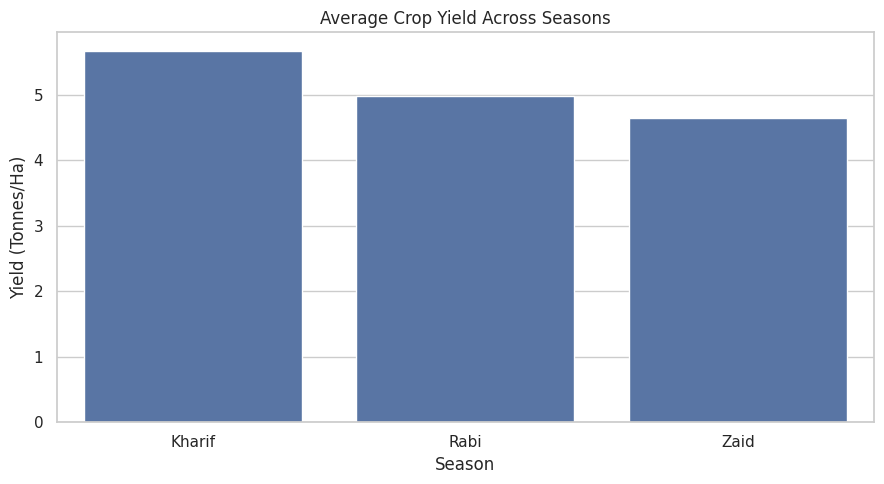

In [46]:
# ============================================================
# 9. AVERAGE YIELD BY SEASON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

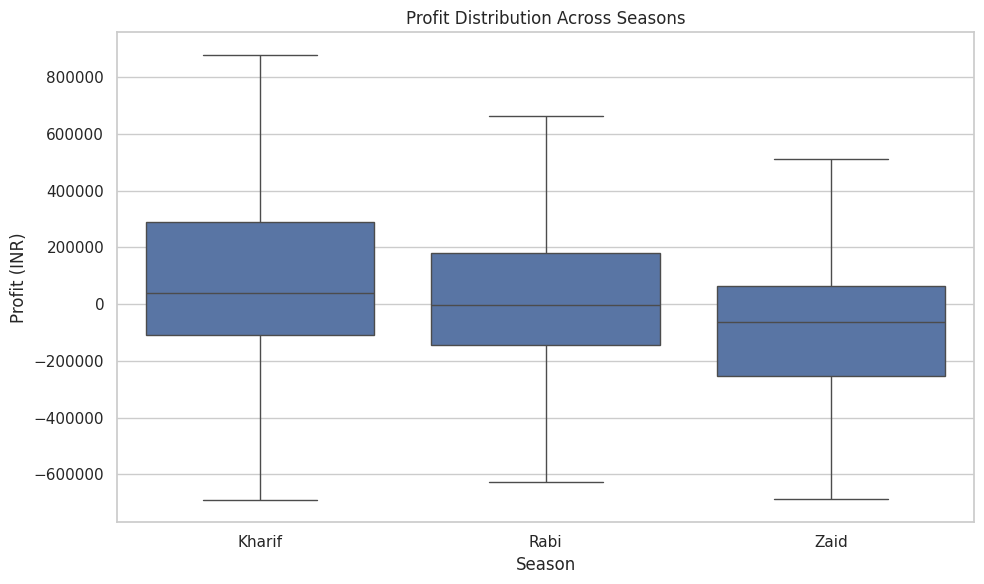

In [47]:
# ============================================================
# 10. PROFIT DISTRIBUTION BY SEASON
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR",
    showfliers=False
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

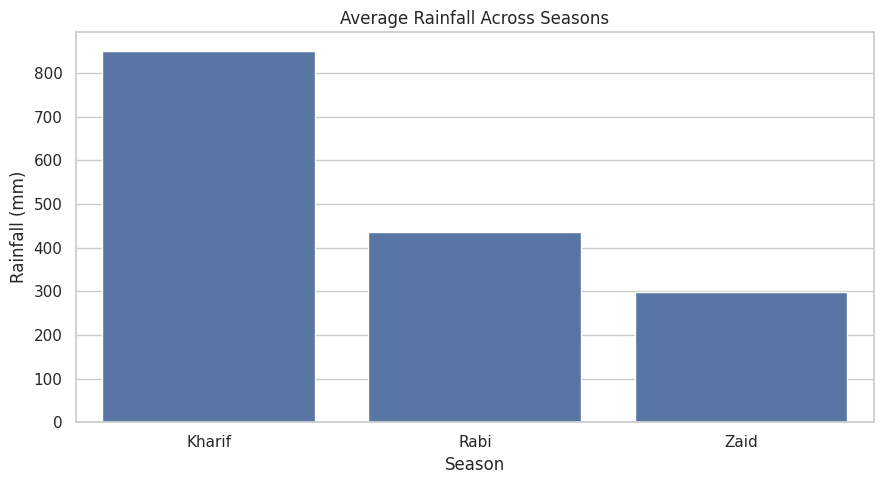

In [48]:
# ============================================================
# 11. RAINFALL BY SEASON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Rainfall_mm",
    errorbar=None
)

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

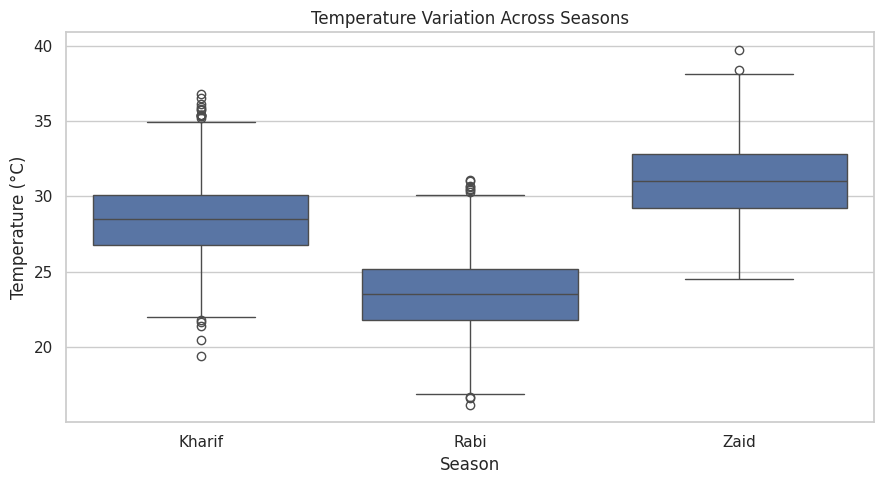

In [76]:
# ============================================================
# 12. TEMPERATURE BY SEASON
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Temperature Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

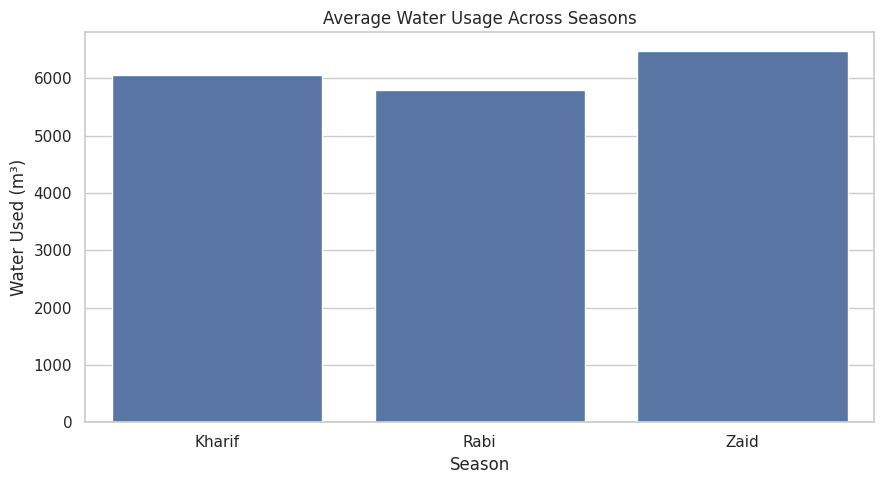

In [50]:
# ============================================================
# 13. WATER USAGE BY SEASON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    errorbar=None
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

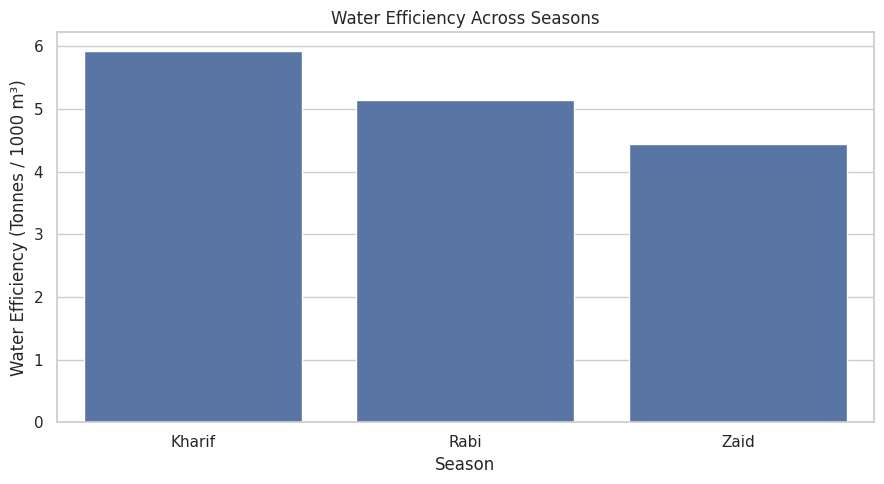

In [51]:
# ============================================================
# 14. WATER EFFICIENCY BY SEASON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    errorbar=None
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")

plt.tight_layout()
plt.show()

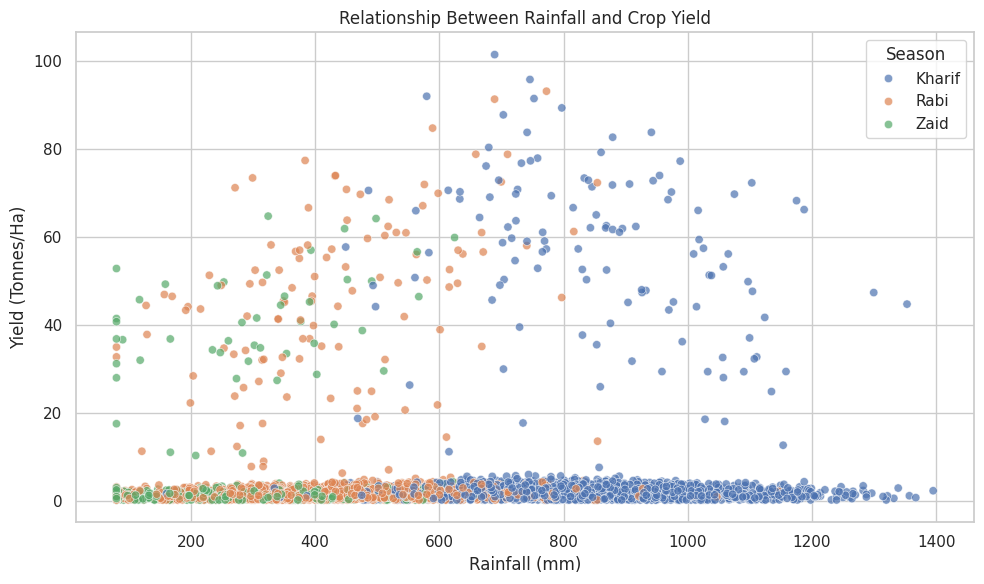

Rainfall-Yield Correlation: 0.03


In [52]:
# ============================================================
# 15. RAINFALL VS YIELD
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    "Rainfall-Yield Correlation:",
    round(rainfall_yield_corr, 3)
)

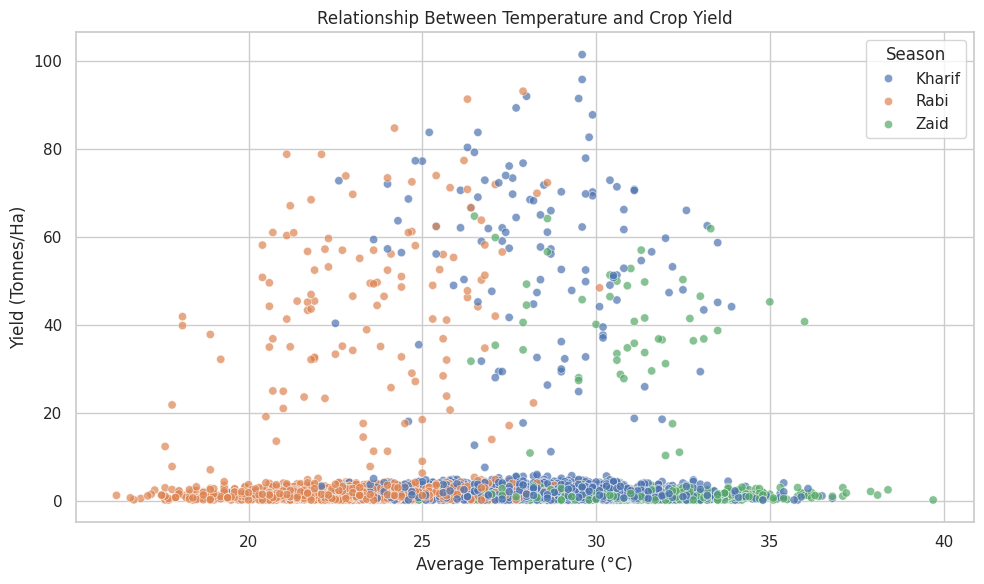

Temperature-Yield Correlation: 0.01


In [53]:
# ============================================================
# 16. TEMPERATURE VS YIELD
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Temperature and Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

temperature_yield_corr = df[
    ["Avg_Temperature_C", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    "Temperature-Yield Correlation:",
    round(temperature_yield_corr, 3)
)

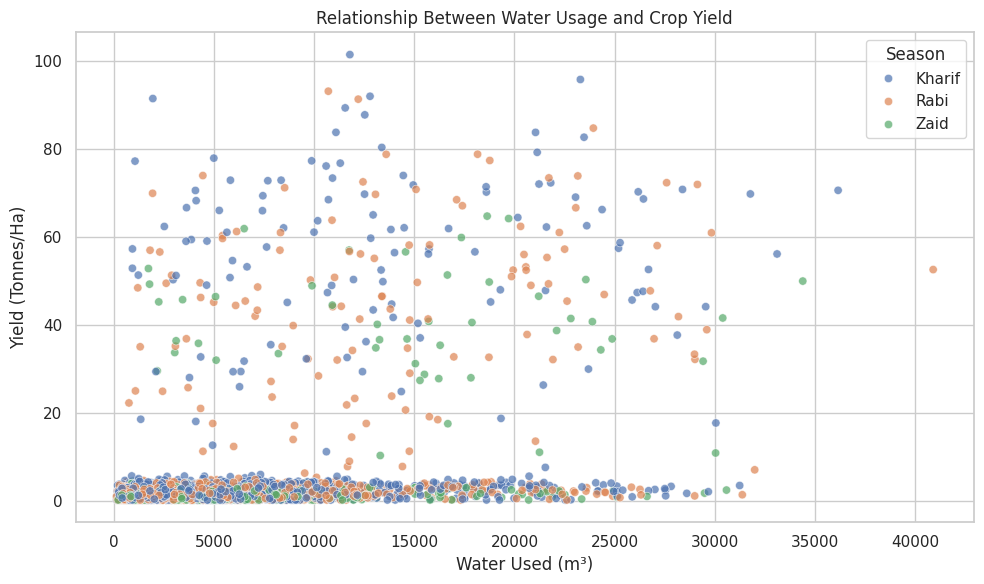

Water Usage-Yield Correlation: 0.391


In [54]:
# ============================================================
# 17. WATER USAGE VS YIELD
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Water Usage and Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

water_yield_corr = df[
    ["Water_Used_m3", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    "Water Usage-Yield Correlation:",
    round(water_yield_corr, 3)
)

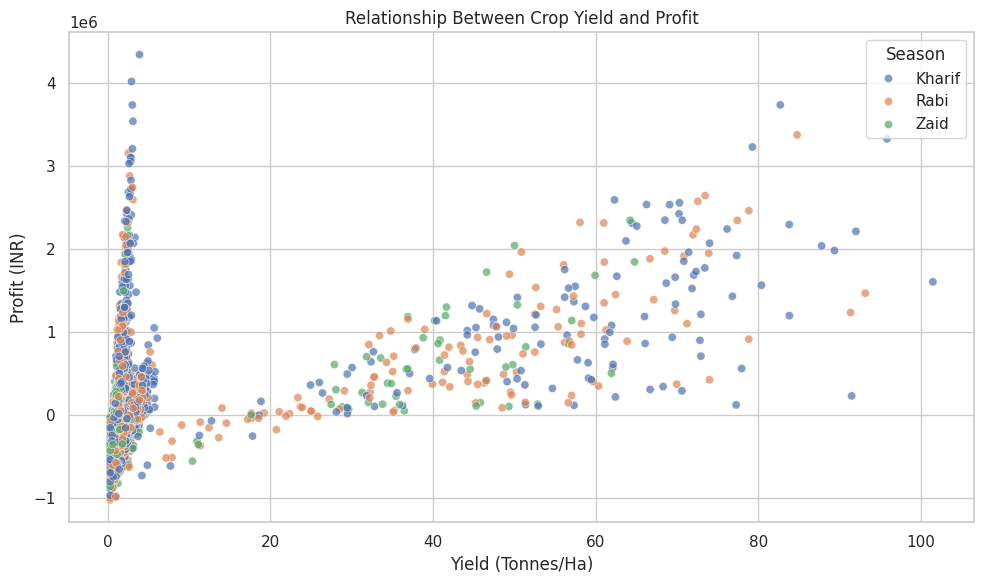

Yield-Profit Correlation: 0.489


In [55]:
# ============================================================
# 18. YIELD VS PROFIT
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Crop Yield and Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

yield_profit_corr = df[
    ["Yield_Tonnes_Ha", "Profit_INR"]
].corr().iloc[0, 1]

print(
    "Yield-Profit Correlation:",
    round(yield_profit_corr, 3)
)

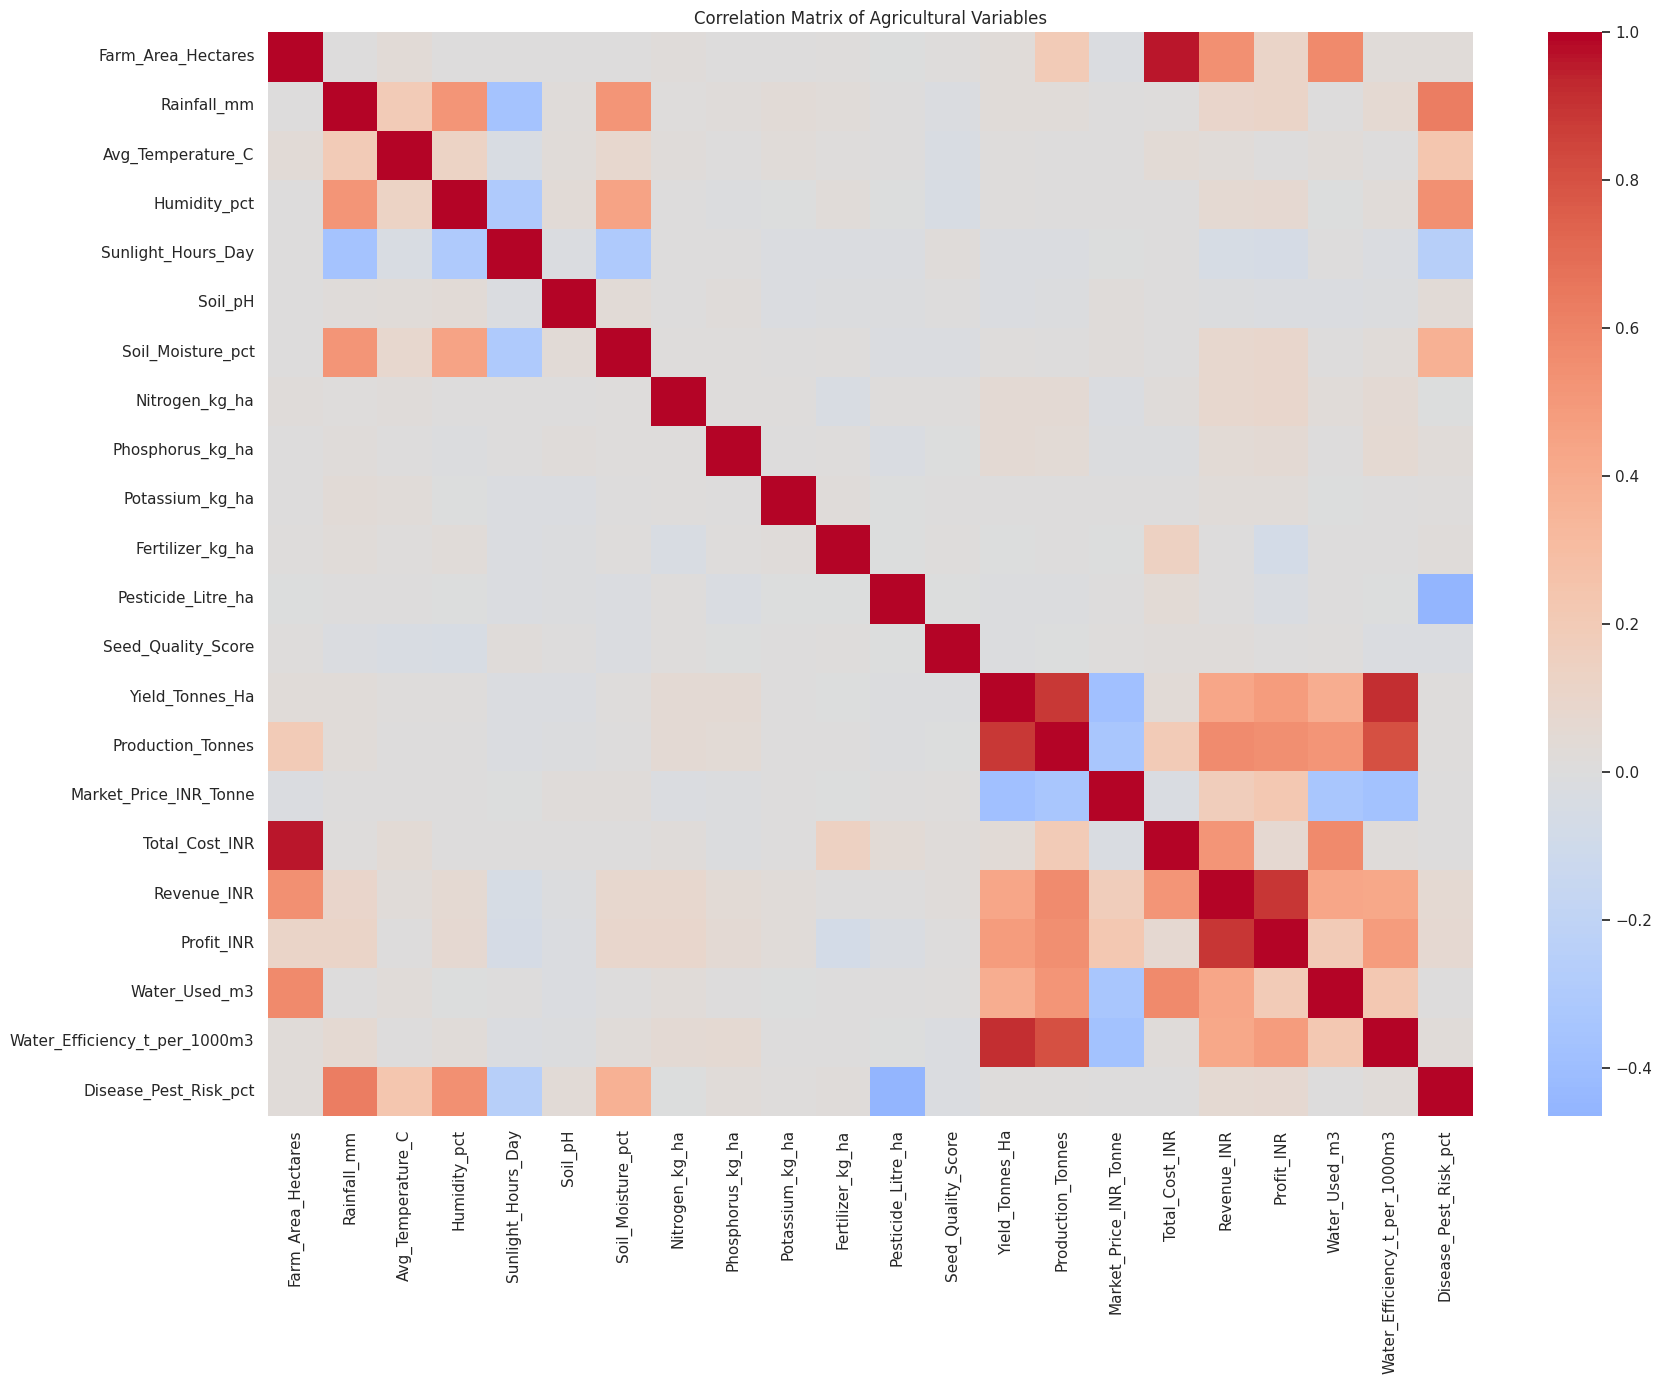

In [56]:
# ============================================================
# 19. CORRELATION HEATMAP
# ============================================================

important_numeric = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

available_columns = [
    col for col in important_numeric
    if col in df.columns
]

correlation_matrix = df[available_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# 20. CROP-WISE PERFORMANCE
# ============================================================

crop_summary = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Use=("Water_Used_m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values(
    "Average_Yield",
    ascending=False
).round(2)

display(crop_summary)

,Average_Yield,Average_Profit,Average_Water_Use,Average_Risk
Crop,,,,
Sugarcane,47.23,"826,120.09","13,919.81",45.47
Maize,2.72,"-80,164.15","4,321.79",45.56
Rice,2.44,"-101,306.32","10,881.63",46.53
Wheat,2.11,"-124,290.65","4,082.90",47.85
Chilli,1.54,"751,488.54","4,555.21",46.09
Groundnut,1.31,"41,955.75","3,456.95",46.30
Cotton,1.23,"125,927.10","5,379.30",46.00
Pulses,0.92,"-3,131.58","2,816.11",46.62


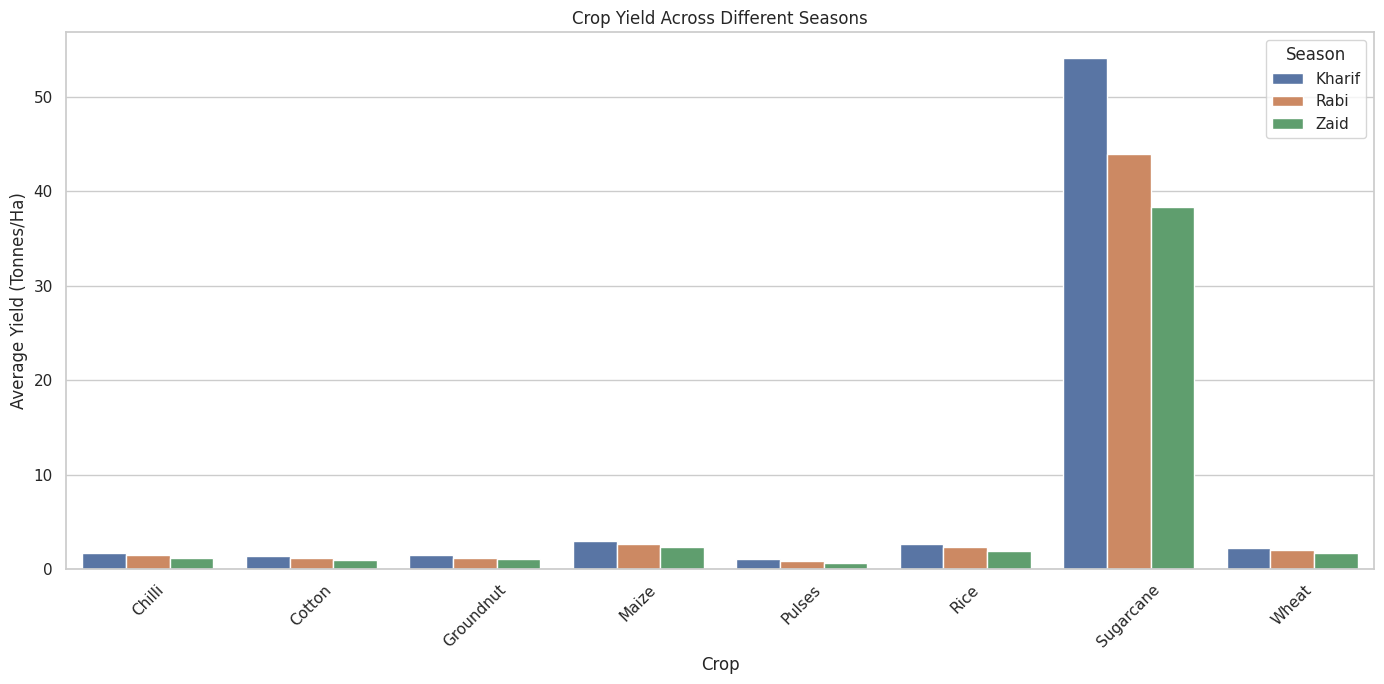

In [58]:
# ============================================================
# 21. CROP VS SEASON YIELD
# ============================================================

crop_season = df.groupby(
    ["Crop", "Season"]
)["Yield_Tonnes_Ha"].mean().reset_index()

plt.figure(figsize=(14, 7))

sns.barplot(
    data=crop_season,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Crop Yield Across Different Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# 22. STATE-WISE PERFORMANCE
# ============================================================

state_summary = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Use=("Water_Used_m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values(
    "Average_Yield",
    ascending=False
).round(2)

display(state_summary)

,Average_Yield,Average_Profit,Average_Water_Use,Average_Risk
State,,,,
Punjab,6.21,"140,325.00","6,567.25",45.99
Karnataka,5.64,"119,169.05","6,347.10",46.00
Gujarat,5.57,"116,692.60","6,075.00",46.07
Maharashtra,5.10,"140,375.85","5,944.34",46.42
Madhya Pradesh,5.08,"91,753.80","5,624.54",47.18
Telangana,5.05,"103,913.93","5,780.08",46.34
Tamil Nadu,4.75,"120,821.68","5,777.36",46.44
Andhra Pradesh,4.59,"68,536.78","5,985.10",46.70


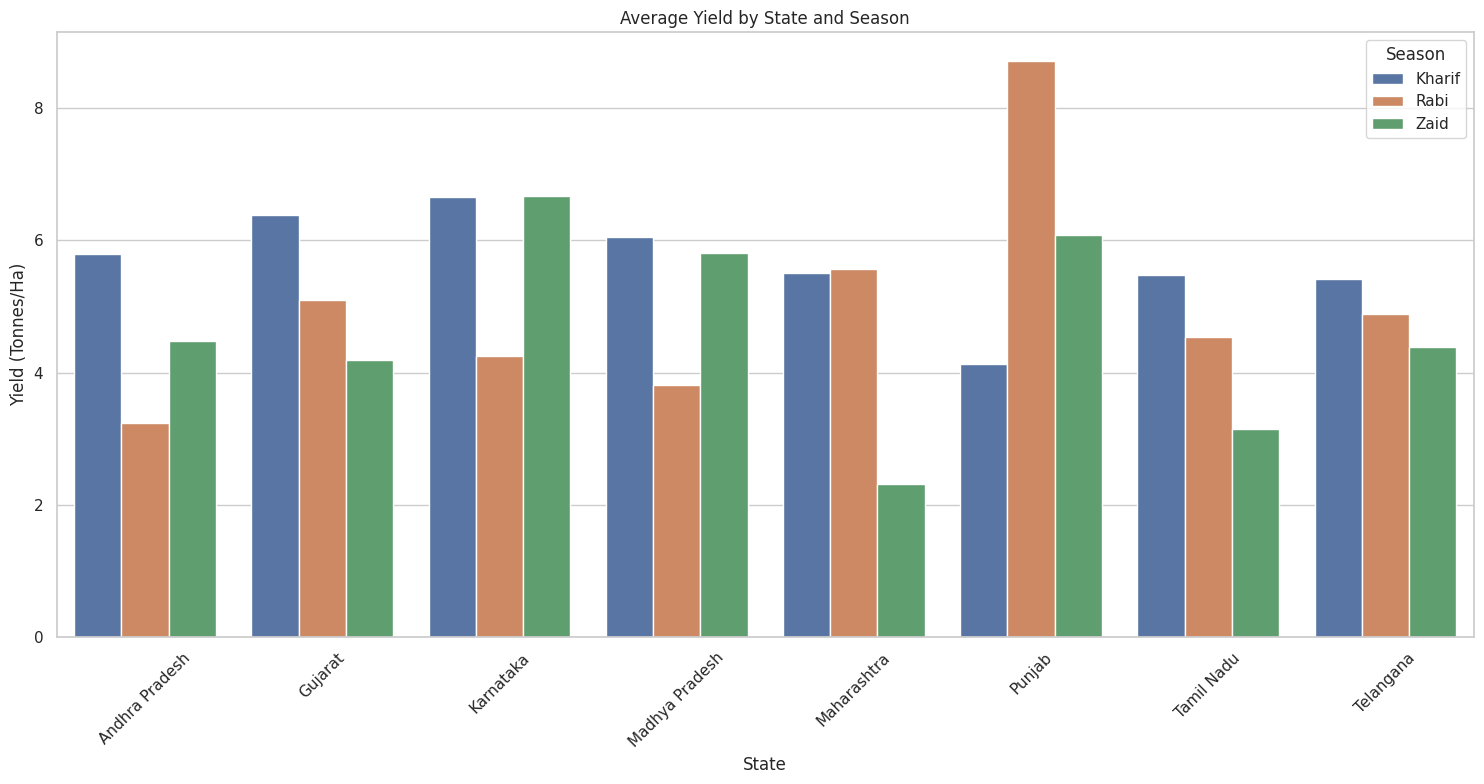

In [60]:
# ============================================================
# 23. STATE VS SEASON YIELD
# ============================================================

state_season = df.groupby(
    ["State", "Season"]
)["Yield_Tonnes_Ha"].mean().reset_index()

plt.figure(figsize=(15, 8))

sns.barplot(
    data=state_season,
    x="State",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Average Yield by State and Season")
plt.xlabel("State")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# 24. IRRIGATION METHOD ANALYSIS
# ============================================================

irrigation_summary = df.groupby(
    "Irrigation_Method"
).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Use=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )
).sort_values(
    "Average_Yield",
    ascending=False
).round(2)

display(irrigation_summary)

,Average_Yield,Average_Profit,Average_Water_Use,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.44,"217,179.46","5,843.82",6.12
Sprinkler,5.25,"97,462.54","6,212.35",4.74
Flood,4.87,"74,646.09","8,006.97",3.44
Rainfed,4.65,"77,264.74","3,547.78",7.61


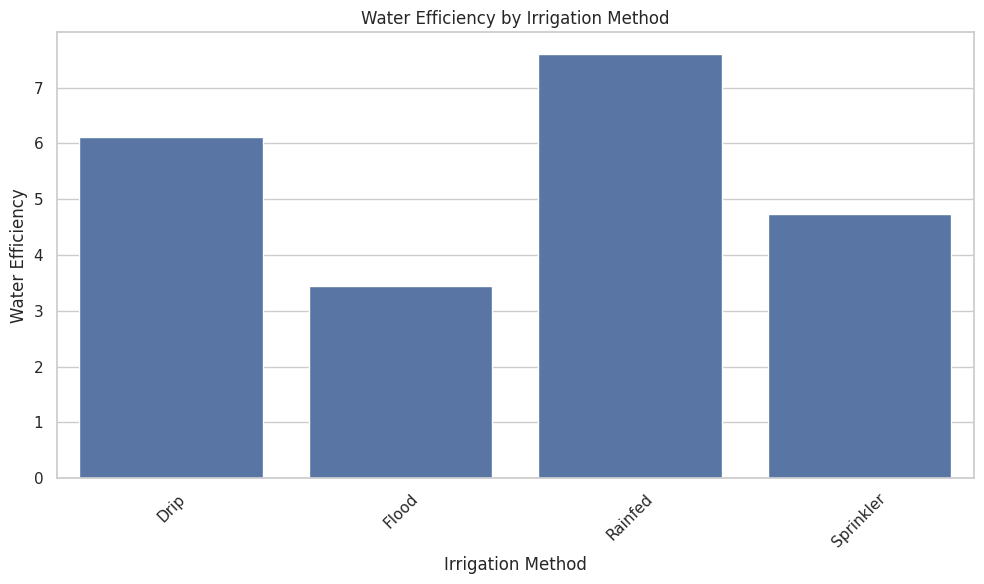

In [62]:
# ============================================================
# 25. IRRIGATION METHOD VS WATER EFFICIENCY
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    errorbar=None
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# 26. DISEASE AND PEST RISK BY SEASON
# ============================================================

risk_summary = df.groupby(
    "Season"
)["Disease_Pest_Risk_pct"].mean().sort_values(
    ascending=False
)

print("Disease and Pest Risk by Season")

display(risk_summary.round(2))

Disease and Pest Risk by Season


,Disease_Pest_Risk_pct
Season,
Kharif,54.45
Rabi,40.52
Zaid,38.11


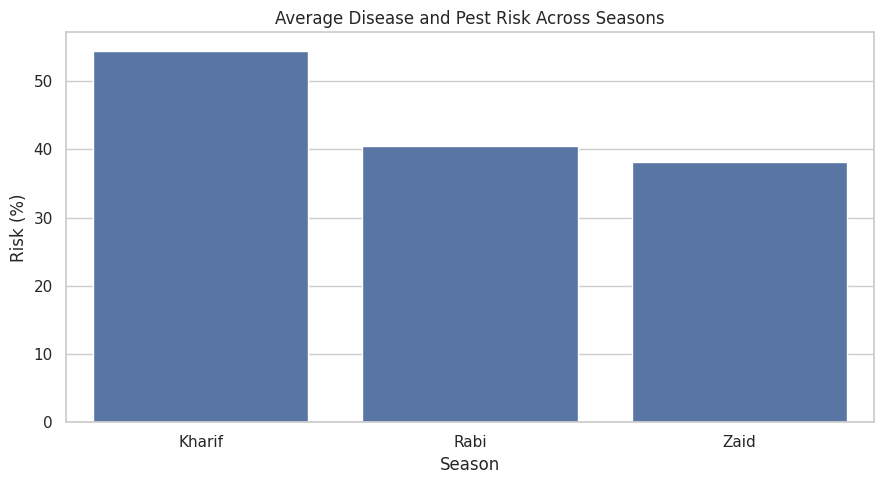

,Disease_Pest_Risk_pct
Season,
Kharif,54.45
Rabi,40.52
Zaid,38.11


In [65]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct",
    errorbar=None
)

plt.title("Average Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.tight_layout()
plt.show()
display(risk_summary.round(2))

In [66]:
# ============================================================
# 27. SOIL CONDITIONS BY SEASON
# ============================================================

soil_summary = df.groupby("Season").agg(
    Average_Soil_pH=("Soil_pH", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
    Average_Nitrogen=("Nitrogen_kg_ha", "mean"),
    Average_Phosphorus=("Phosphorus_kg_ha", "mean"),
    Average_Potassium=("Potassium_kg_ha", "mean")
).round(2)

display(soil_summary)

,Average_Soil_pH,Average_Soil_Moisture,Average_Nitrogen,Average_Phosphorus,Average_Potassium
Season,,,,,
Kharif,6.73,31.20,120.08,58.04,105.25
Rabi,6.67,24.07,120.21,57.34,103.75
Zaid,6.69,19.18,120.31,58.26,105.19


In [67]:
# ============================================================
# 28. FARM INPUTS VS YIELD
# ============================================================

input_variables = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha"
]

input_correlations = df[
    input_variables + ["Yield_Tonnes_Ha"]
].corr()["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

print("Correlation of Farm Inputs with Yield")

display(input_correlations.round(3))

Correlation of Farm Inputs with Yield


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Nitrogen_kg_ha,0.06
Phosphorus_kg_ha,0.05
Potassium_kg_ha,0.00
Fertilizer_kg_ha,-0.00
Pesticide_Litre_ha,-0.01
Seed_Quality_Score,-0.01


In [68]:
# ============================================================
# 29. PROFITABILITY ANALYSIS
# ============================================================

df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)

profitability = df.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Profit_Margin=("Profit_Margin_pct", "mean")
).round(2)

display(profitability)

,Average_Revenue,Average_Cost,Average_Profit,Average_Profit_Margin
Season,,,,
Kharif,"712,489.58","530,950.56","181,539.02",-38.22
Rabi,"598,348.82","512,126.73","86,222.09",-43.73
Zaid,"518,555.62","545,191.30","-26,635.69",-68.61


In [69]:
# ============================================================
# 30. PROFIT VS LOSS CLASSIFICATION
# ============================================================

df["Financial_Status"] = np.where(
    df["Profit_INR"] >= 0,
    "Profit",
    "Loss"
)

financial_summary = df[
    "Financial_Status"
].value_counts()

print("Financial Status of Farms")

display(financial_summary)

Financial Status of Farms


,count
Financial_Status,
Profit,1978
Loss,1902


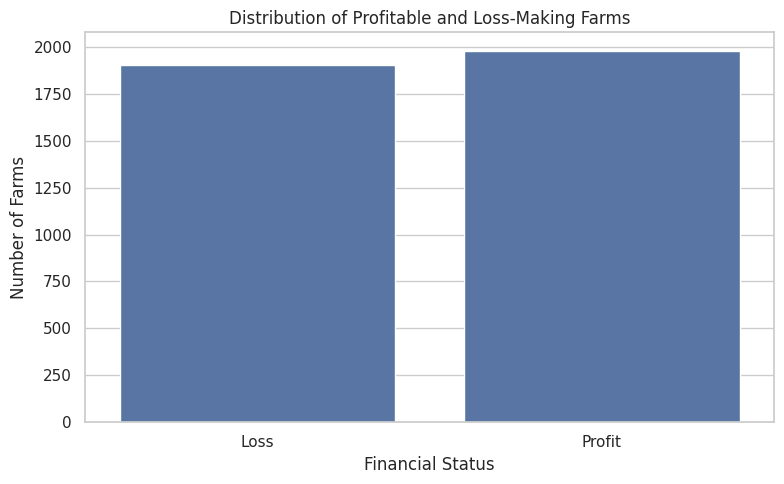

In [70]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Financial_Status"
)

plt.title("Distribution of Profitable and Loss-Making Farms")
plt.xlabel("Financial Status")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# 31. OUTLIER ANALYSIS
# ============================================================

def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers, lower, upper


outlier_columns = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Rainfall_mm",
    "Production_Tonnes"
]

for column in outlier_columns:

    outliers, lower, upper = detect_outliers(
        df,
        column
    )

    print("\n------------------------------------")
    print("Variable:", column)
    print("Lower boundary:", round(lower, 2))
    print("Upper boundary:", round(upper, 2))
    print("Outlier count:", len(outliers))


------------------------------------
Variable: Yield_Tonnes_Ha
Lower boundary: -1.63
Upper boundary: 5.5
Outlier count: 293

------------------------------------
Variable: Profit_INR
Lower boundary: -696340.0
Upper boundary: 764130.0
Outlier count: 387

------------------------------------
Variable: Water_Used_m3
Lower boundary: -6053.38
Upper boundary: 16091.62
Outlier count: 265

------------------------------------
Variable: Rainfall_mm
Lower boundary: -324.46
Upper boundary: 1530.04
Outlier count: 0

------------------------------------
Variable: Production_Tonnes
Lower boundary: -23.91
Upper boundary: 53.23
Outlier count: 318


In [72]:
# ============================================================
# 32. BEST AND WORST SEASON IDENTIFICATION
# ============================================================

print("BEST AND WORST SEASON ANALYSIS")
print("--------------------------------")

best_yield = season_summary[
    "Average_Yield"
].idxmax()

worst_yield = season_summary[
    "Average_Yield"
].idxmin()

best_profit = season_summary[
    "Average_Profit"
].idxmax()

worst_profit = season_summary[
    "Average_Profit"
].idxmin()

best_water_efficiency = season_summary[
    "Average_Water_Efficiency"
].idxmax()

highest_risk = season_summary[
    "Average_Pest_Risk"
].idxmax()

print("Highest average yield:", best_yield)
print("Lowest average yield:", worst_yield)

print("Highest average profit:", best_profit)
print("Lowest average profit:", worst_profit)

print(
    "Highest water efficiency:",
    best_water_efficiency
)

print(
    "Highest disease/pest risk:",
    highest_risk
)

BEST AND WORST SEASON ANALYSIS
--------------------------------
Highest average yield: Kharif
Lowest average yield: Zaid
Highest average profit: Kharif
Lowest average profit: Zaid
Highest water efficiency: Kharif
Highest disease/pest risk: Kharif


In [73]:
# ============================================================
# 33. TOP PERFORMING CROPS
# ============================================================

top_crop = crop_summary[
    "Average_Yield"
].idxmax()

lowest_crop = crop_summary[
    "Average_Yield"
].idxmin()

highest_profit_crop = crop_summary[
    "Average_Profit"
].idxmax()

print("Highest yielding crop:", top_crop)
print("Lowest yielding crop:", lowest_crop)
print("Highest average profit crop:", highest_profit_crop)

Highest yielding crop: Sugarcane
Lowest yielding crop: Pulses
Highest average profit crop: Sugarcane


In [74]:
# ============================================================
# 34. IMPORTANT CORRELATIONS
# ============================================================

target = "Yield_Tonnes_Ha"

yield_correlations = df[
    numeric_columns
].corr()[target].sort_values(
    ascending=False
)

print("VARIABLES MOST ASSOCIATED WITH YIELD")

display(yield_correlations.round(3))

VARIABLES MOST ASSOCIATED WITH YIELD


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.92
Production_Tonnes,0.89
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.06
Phosphorus_kg_ha,0.05
Total_Cost_INR,0.03
Farm_Area_Hectares,0.03


In [75]:
# ============================================================
# 35. FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 70)

print("\nDATASET")
print("Number of records:", len(df))
print("Number of variables:", len(df.columns))

print("\nSEASONAL PERFORMANCE")
print("Highest average yield:", best_yield)
print("Lowest average yield:", worst_yield)

print("Highest average profit:", best_profit)
print("Lowest average profit:", worst_profit)

print("Highest water efficiency:", best_water_efficiency)

print("Highest pest/disease risk:", highest_risk)

print("\nCROP PERFORMANCE")
print("Highest yielding crop:", top_crop)
print("Lowest yielding crop:", lowest_crop)

print("\nFINANCIAL PERFORMANCE")
print("Profitable farms:",
      (df["Financial_Status"] == "Profit").sum())

print("Loss-making farms:",
      (df["Financial_Status"] == "Loss").sum())

print("\nAnalysis completed successfully.")

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS

DATASET
Number of records: 3880
Number of variables: 30

SEASONAL PERFORMANCE
Highest average yield: Kharif
Lowest average yield: Zaid
Highest average profit: Kharif
Lowest average profit: Zaid
Highest water efficiency: Kharif
Highest pest/disease risk: Kharif

CROP PERFORMANCE
Highest yielding crop: Sugarcane
Lowest yielding crop: Pulses

FINANCIAL PERFORMANCE
Profitable farms: 1978
Loss-making farms: 1902

Analysis completed successfully.
